**This notebook tries to find CL09's missing neu5ac/gc transporter**

*Assumptions*
1. Will not be a direct match for anything in the ATCC genome
    - there won't be a reciprocal-BLAST hit 
2. Will be overexpressed in sialic vs glucose

**Read in the genome and DeSeq data**

In [102]:
import pandas as pd
import os 

### read in the GFFs 
def get_gff(gffpath):

    atcc_gff = pd.read_csv(gffpath, sep = "\t",
    comment='#', header=None).dropna(subset = 1)
    loci = atcc_gff[[3,4,6]].rename(columns = {3: 'start', 4: 'end', 6: 'strand'})
    atcc_gff = list(atcc_gff[8].apply(lambda x: str(x).split(';')))
    atcc_gff = [{a.split('=')[0]: a.split('=')[1] for a in b} \
        for b in [x for x in atcc_gff if len(x) > 3]]
    atcc_gff = pd.DataFrame(atcc_gff)
    atcc_gff = loci.join(atcc_gff).set_index('ID')
    return atcc_gff

atcc_gff = get_gff('../ref_genomes/prokka_ATCC8482/ATCC8482.gff')
cl09_gff = get_gff('../ref_genomes/prokka_CL09/CL09.gff')

### and the reciprocal blast hits 
genome_map = pd.read_csv('../ref_genomes/ATCC8482_to_CL09_rbh_gene_map.tsv', sep = "\t")

### and the sialic acid results 
cl09 = pd.read_csv("results/cl09.sialic.tsv", sep = "\t", index_col=0)
atcc = pd.read_csv("results/atcc.sialic.tsv", sep = "\t", index_col=0)

##
sample_map = pd.read_csv('../rna_seq/samples.csv', header=None,
 names=['sampleID', 'seqpath','genome','strain','treatment']).set_index('sampleID').drop(columns = 'seqpath')

### and the counts
def load_tpms(samples):
    rna_seq_path = '../rna_seq/vulgatus_processed/'
    tpmdf = []
    for sample in samples:
        spath = os.path.join(rna_seq_path, sample, sample + '.mapped.counts.txt')
        tpmdf.append(pd.read_csv(spath, sep = '\t', index_col=0)[['tpm']].rename(columns = {'tpm': sample}).transpose())
    tpmdf = pd.concat(tpmdf)
    return tpmdf

CL09_samples = sample_map[sample_map['strain'] == 'CL09'].index
ATCC_samples = sample_map[sample_map['strain'] == 'ATCC'].index

CL09_tpms = load_tpms(CL09_samples)
ATCC_tpms = load_tpms(ATCC_samples)

/var/folders/_p/0rhlx8c56pgffwnwkjz824s80000gn/T/ipykernel_81251/4083929491.py:7: DtypeWarning: Columns (1,2,5,6,7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  atcc_gff = pd.read_csv(gffpath, sep = "\t",
/var/folders/_p/0rhlx8c56pgffwnwkjz824s80000gn/T/ipykernel_81251/4083929491.py:7: DtypeWarning: Columns (1,2,5,6,7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  atcc_gff = pd.read_csv(gffpath, sep = "\t",


**pull out non-shared genes that are up in sialic acid**

In [116]:
# up with p<0.05
cl09_up = cl09[(cl09['padj'] < 0.05) & (cl09['log2FoldChange'] > 0)].copy()
atcc_up = atcc[(atcc['padj'] < 0.05) & (atcc['log2FoldChange'] > 0)].copy()

## find genes that are up and unique to each genome
atcc_unique_up = set(atcc_up.index) - set(genome_map['ATCC8482_locus_tag'])
atcc_non_unique_up = set(atcc_up.index) & set(genome_map['ATCC8482_locus_tag'])

cl09_unique_up = set(cl09_up.index) - set(genome_map['CL09_locus_tag'])
cl09_non_unique_up = set(cl09_up.index) & set(genome_map['CL09_locus_tag'])

### shared genes that are up in both 
both_up = genome_map[genome_map['CL09_locus_tag'].isin(list(cl09_up.index)) & genome_map['ATCC8482_locus_tag'].isin(list(atcc_up.index))]


print('CL09')
print('total upregulated:', len(cl09_up))
print('unique to CL09:', len(cl09_unique_up), '(', round(len(cl09_unique_up)/len(cl09_up)*100, 2), '%)')
print('-'*20)
print('ATCC')
print('total upregulated:', len(atcc_up))
print('unique to ATCC:', len(atcc_unique_up), '(', round(len(atcc_unique_up)/len(atcc_up)*100, 2), '%)')
print('-'*20)
print('shared genes that are up in both:', both_up.shape[0])

CL09
total upregulated: 1361
unique to CL09: 154 ( 11.32 %)
--------------------
ATCC
total upregulated: 1241
unique to ATCC: 191 ( 15.39 %)
--------------------
shared genes that are up in both: 874


**check annotations for anything sus-like**

In [110]:
cl09_gff.loc[list(cl09_unique_up)][cl09_gff.loc[list(cl09_unique_up)]['product'].fillna('').str.contains('Sus')]

,start,end,strand,inference,locus_tag,product,eC_number,Name,db_xref,gene,note,Alias,Dbxref,rpt_family,rpt_type,rpt_unit_seq
ID,,,,,,,,,,,,,,,,
BHNFMJIF_02259,1064766.0,1068050.0,+,"ab initio prediction:Prodigal:v2.6,similar to ...",BHNFMJIF_02259,TonB-dependent receptor SusC,NaN,susC_12,COG:COG1629,susC_12,NaN,NaN,NaN,NaN,NaN,NaN
BHNFMJIF_02265,1075825.0,1077408.0,+,"ab initio prediction:Prodigal:v2.6,similar to ...",BHNFMJIF_02265,SusD-like protein P38,NaN,NaN,COG:COG0702,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [120]:
both_up[both_up['ATCC8482_product'].str.contains('Sus') | both_up['CL09_product'].str.contains('sus')]

,ATCC8482_locus_tag,CL09_locus_tag,ATCC8482_gene,CL09_gene,ATCC8482_product,CL09_product,forward_bitscore,reverse_bitscore,forward_pident,reverse_pident,forward_qcovs,reverse_qcovs
402,JJAGMNAF_00532,BHNFMJIF_02320,NaN,NaN,SusD-like protein P38,SusD-like protein P38,1078.0,1078.0,99.613,99.613,100.0,100.0
504,JJAGMNAF_00648,BHNFMJIF_02202,susB_1,susB_2,"Glucan 1,4-alpha-glucosidase SusB","Glucan 1,4-alpha-glucosidase SusB",1303.0,1303.0,99.106,99.106,100.0,100.0
736,JJAGMNAF_01092,BHNFMJIF_01819,susC_9,susC_8,TonB-dependent receptor SusC,TonB-dependent receptor SusC,1962.0,1996.0,99.605,99.803,100.0,100.0
2930,JJAGMNAF_04250,BHNFMJIF_02528,NaN,NaN,SusD-like protein P2,SusD-like protein P2,1004.0,1004.0,99.600,99.600,100.0,100.0


**plot expression level of putative susC/D**

Text(0, 0.5, '')

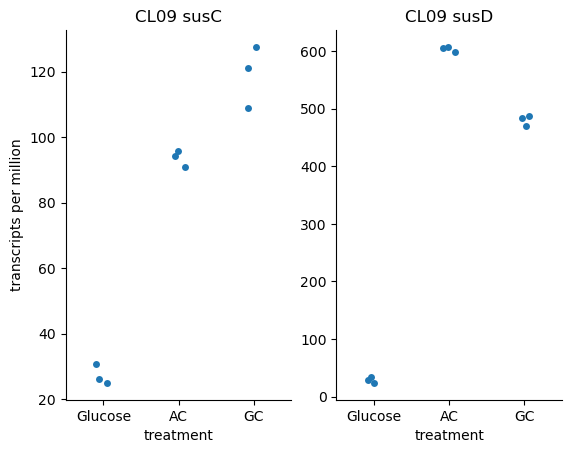

In [143]:
import matplotlib.pyplot as plt
import seaborn as sns 

to_gene = {'BHNFMJIF_02259': 'susC', 'BHNFMJIF_02265': 'susD'}

transport_data = CL09_tpms[list(to_gene.keys() )].join(sample_map, how = 'left').rename(columns = to_gene)

fig, ax = plt.subplots(1,2)
sns.despine()

sns.stripplot(data = transport_data, x = 'treatment', y = 'susC', ax = ax[0])
sns.stripplot(data = transport_data, x = 'treatment', y = 'susD', ax = ax[1])
ax[0].set_title('CL09 susC')
ax[1].set_title('CL09 susD')
ax[0].set_ylabel('transcripts per million')
ax[1].set_ylabel('')


**vs all other genes**

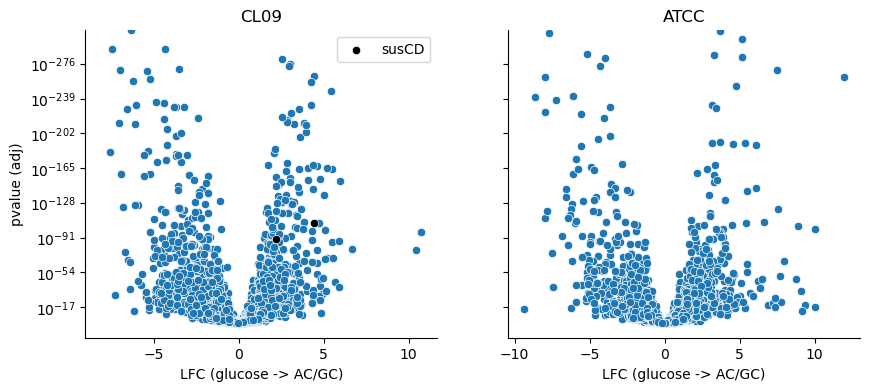

In [162]:
fig, ax = plt.subplots(1,2, figsize = (10,4), sharey=True)
ax[0].set_title('CL09')
ax[1].set_title('ATCC')
sns.despine()
sns.scatterplot(data = cl09, x = 'log2FoldChange', y = 'padj', ax = ax[0])
sns.scatterplot(data = cl09.loc[to_gene.keys()], x = 'log2FoldChange', y = 'padj', ax = ax[0],
    color = 'black', label='susCD')

sns.scatterplot(data = atcc, x = 'log2FoldChange', y = 'padj', ax = ax[1])

ax[0].set_ylabel('pvalue (adj)')

ax[0].set_xlabel('LFC (glucose -> AC/GC)')
ax[1].set_xlabel('LFC (glucose -> AC/GC)')
plt.gca().invert_yaxis()
plt.yscale('log')